<a href="https://colab.research.google.com/github/YazGonzalezHerrera/Simulaci-n-II/blob/main/Caminata%20aleatoria%20sobre%20un%20grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Caminata Aleatoria sobre un grafo**

Un grafo es un conjunto de nodos (vertices) y ejes (arcos).

Para generar este algoritmo, consideramos una secuencia de $0^r$$^s$ y $1^r$$^s$ de longitud m.
Llamaremos una **buena cadena** a la que no contenga $1^r$$^s$ adyacentes.

Una cadena de longitud $m$, el valor esperado de $1^r$$^s$ es:

$\mu  = \sum_kk\pi_k$

donde $\pi_k$ es la probabilidad de que una buena secuencia tenga $k$ $1^r$$^s$

Si $x$ es una secuencia de de $0^´$$^s$ y $1^´$$^s$ de longitud $m$. Sea $r(x)$ el número de $1^´$$^s$ en la secuencia.

Si nos restingimos a simular solo buenas cadenas $Y_0, Y_1, Y_2, ...$ podemos estimar las respuestas por Método de Monte Carlo

$\mu  = \frac{r(Y_0) + r(Y_1) + \ldotp \ldotp \ldotp  + r(Y_n)}{n}$

La metología seria proceder por aceptación y rechazo, generamos muchas cadenas y solo guardamos buenas cadenas.

**Ejercicio**

Si m=100, ¿Cuántas buenas cadenas hay?

**Solución**

Para m=100, el espacio de estados seria $2^1$$^0$$^0$, es enorme. Por lo que intentar generar todas las secuencias o crear la matriz de transición completa de todos los estados generaria un error al programarlo.

In [17]:
import random
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# Verificar si una cadena es "buena" (sin 1s adyacentes)

def es_buena(cadena):
    for i in range(len(cadena) - 1):
        if cadena[i] == 1 and cadena[i + 1] == 1:
            return False
    return True

# Paso de la caminata aleatoria, comprueba solo los vecinos de la posición actual

def caminata_aleatoria(cadena):
    m = len(cadena)
    pos = random.randint(0, m - 1)
    nueva = cadena.copy()

    if cadena[pos] == 1:
        # Cuando 1 -> 0: Siempre es válido
        nueva[pos] = 0
        return nueva, pos, True
    else:
        # Cuando 0 -> 1: Verificar solo los vecinos inmediatos
        izquierda_ok = (pos == 0) or (cadena[pos - 1] == 0)
        derecha_ok = (pos == m - 1) or (cadena[pos + 1] == 0)

        if izquierda_ok and derecha_ok:
            nueva[pos] = 1
            return nueva, pos, True
        else:
            # Se rechaza: nos quedamos en el mismo estado
            return cadena, pos, False

# Valor teórico de μ bajo una distribución uniforme sobre cadenas buenas de longitud m

def mu_teorico(m):
    phi = (1 + np.sqrt(5)) / 2
    return m / (1 + phi)

# Simulación principal para m = 100

if __name__ == "__main__":

    m = 100
    pasos = 500000
    burn_in = 200000

    # Estado inicial: todos ceros (es buena)
    cadena = [0] * m

    print("=" * 65)
    print(f"Caminata aleatoria m = {m}")
    print("=" * 65)
    print(f"Estado inicial: {''.join(map(str, cadena))}")
    print(f"Pasos: {pasos:,}")
    print("-" * 65)

    # Simulación

    historial_r = np.empty(pasos - burn_in, dtype=np.int32)
    historial_mu = np.empty(pasos, dtype=np.float64)
    aceptados = 0
    suma = 0
    k = 0

    for t in range(pasos):
        cadena, pos, exito = caminata_aleatoria(cadena)
        aceptados += int(exito)
        r = sum(cadena)
        suma += r
        historial_mu[t] = suma / (t + 1)

        if t >= burn_in:
            historial_r[k] = r
            k += 1

        if (t + 1) % 100_000 == 0:
            print(f"  Paso {t+1:>8,}: r = {r:>3d}, "
                  f"Tasa de aceptación = {aceptados/(t+1):.4f}")

    # Resultados

    mu_hat   = historial_r.mean()
    sigma    = historial_r.std(ddof=1)
    error    = sigma / np.sqrt(len(historial_r))
    mu_t     = mu_teorico(m)
    tasa     = aceptados / pasos
    phi      = (1 + np.sqrt(5)) / 2

    print("\n" + "=" * 65)
    print("RESULTADOS")
    print("=" * 65)
    print(f"Tasa de aceptación : {tasa:.4f}")
    print(f"μ estimado (MC) : {mu_hat:.5f}  ± {error:.5f}")
    print(f"μ teórico : {mu_t:.5f}")
    print(f"Diferencia : {abs(mu_hat - mu_t):.5f}")
    print(f"Número de buenas cadenas B({m}) = F({m+2}) ≈ "
          f"{phi**(m+2)/np.sqrt(5):.4e}")

Caminata aleatoria m = 100
Estado inicial: 0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000
Pasos: 500,000
-----------------------------------------------------------------
  Paso  100,000: r =  30, Tasa de aceptación = 0.5547
  Paso  200,000: r =  24, Tasa de aceptación = 0.5542
  Paso  300,000: r =  24, Tasa de aceptación = 0.5548
  Paso  400,000: r =  25, Tasa de aceptación = 0.5553
  Paso  500,000: r =  27, Tasa de aceptación = 0.5556

RESULTADOS
Tasa de aceptación : 0.5556
μ estimado (MC) : 27.84212  ± 0.00553
μ teórico : 38.19660
Diferencia : 10.35448
Número de buenas cadenas B(100) = F(102) ≈ 9.2737e+20


Nos da como resultado una tasa esperada de aceptación del 55.6% de los movimientos propuestos en la caminata aleatoria y fueron válidos y aceptados.

Para $\mu$ estimado (Mediante Monte Carlo) nos arroja un promedio estimado del número de $1^´$$^s$ en una buena cadena de longitud $m=100$. El cual hace contraste con $\mu$ téorico.

**Covergencia de $\mu$**

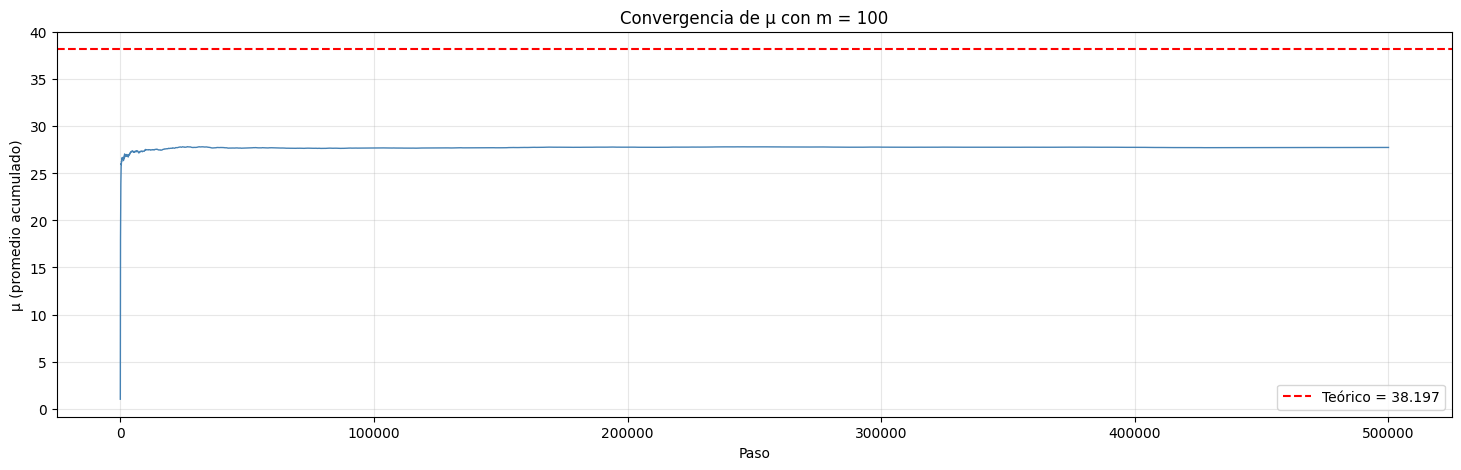

In [15]:
fig, ax = plt.subplots(figsize=(18, 5))

# Convergencia
ax.plot(historial_mu, color="steelblue", lw=1)
ax.axhline(mu_t, color="red", ls="--",
                label=f"Teórico = {mu_t:.3f}")
ax.set_xlabel("Paso")
ax.set_ylabel("μ (promedio acumulado)")
ax.set_title(f"Convergencia de μ con m = {m}")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

La gráfica de la convergencia de $\mu$ muestra como el promedio acumulado se va estabilizando tras superar los 20,000 pasos. Mientras que la linea roja moldea como se ve $\mu$ téorico conforme avanzan los pasos.

**Serie temporal de $r(Y_t)$**

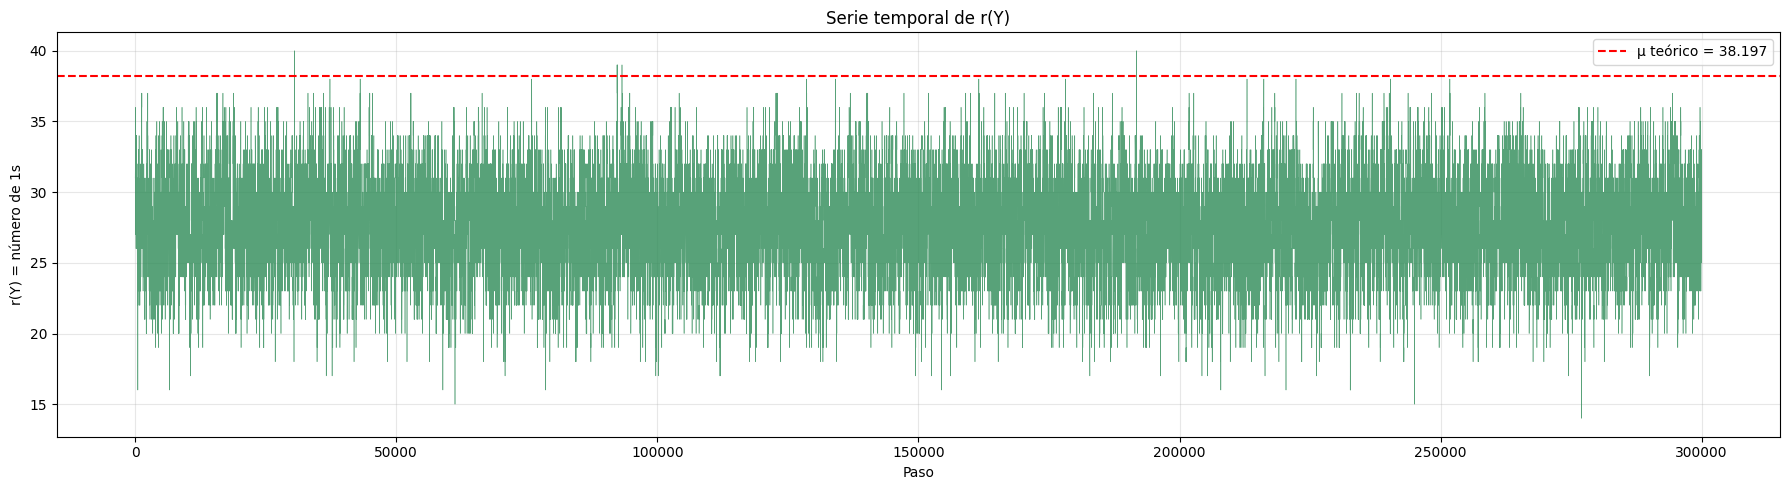

In [14]:
fig, axes = plt.subplots(figsize=(18, 5))

# Serie temporal
axes.plot(historial_r, color="seagreen", lw=0.4, alpha=0.8)
axes.axhline(mu_t, color="red", ls="--",
                label=f"μ teórico = {mu_t:.3f}")
axes.set_xlabel("Paso")
axes.set_ylabel("r(Y) = número de 1s")
axes.set_title("Serie temporal de r(Y)")
axes.legend()
axes.grid(alpha=0.3)

plt.tight_layout()
plt.show()

La serie de tiempo ilustra las fluctuaciones del número de $1^´$$^s$ en la cadena a lo largo del tiempo, muestra que el sistema se encuentra en un estado estacionario rapidamente.

**Histograma de $r(Y)$**

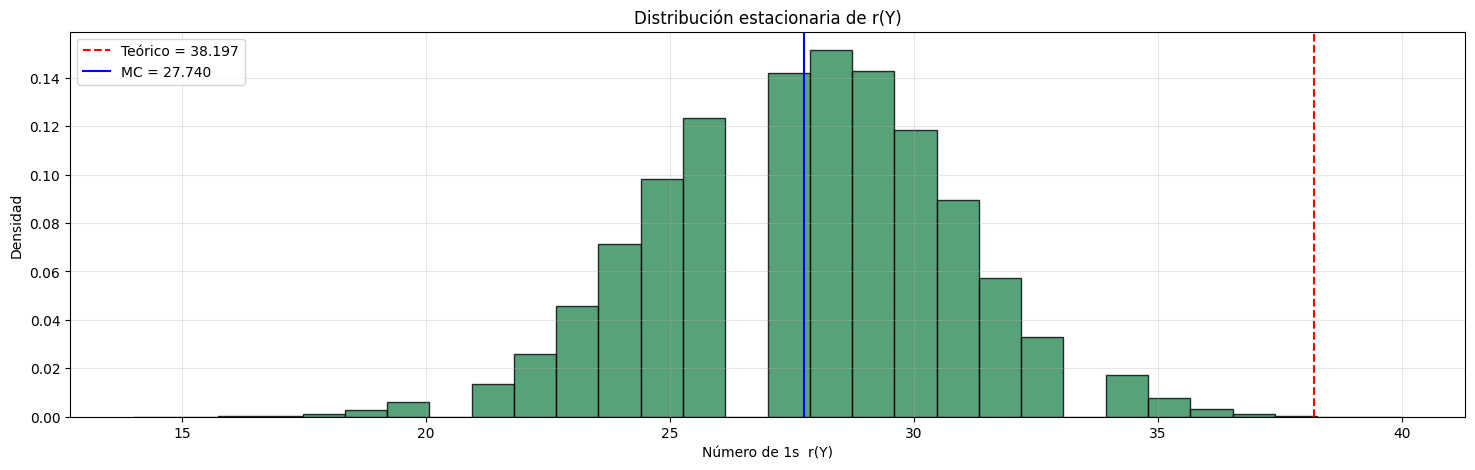

In [16]:
fig, ax = plt.subplots(figsize=(18, 5))

# Histograma de r(Y)
ax.hist(historial_r, bins=30, density=True,
             color="seagreen", alpha=0.8, edgecolor="black")
ax.axvline(mu_t, color="red", ls="--",
                label=f"Teórico = {mu_t:.3f}")
ax.axvline(mu_hat, color="blue", ls="-",
                label=f"MC = {mu_hat:.3f}")
ax.set_xlabel("Número de 1s  r(Y)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución estacionaria de r(Y)")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

La distribución de los datos de $r(Y)$ forman una distribución normal, centrada cerca de $\mu$ estimada.